In [44]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler, LabelEncoder,label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score,roc_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
from itertools import cycle

In [45]:
df = pd.read_csv("CICIDS2017_sample.csv")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head(3)

Dataset loaded successfully!
Shape: (56661, 78)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,4,2,0,37,0,31,6,18.500000,17.677670,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,142377,46,62,1325,105855,570,0,28.804348,111.407285,4344,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,118873,23,28,1169,45025,570,0,50.826087,156.137367,2896,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f"After cleaning: {df.shape}")
print("\nClass distribution:")
print(df['Label'].value_counts())

After cleaning: (56580, 78)

Class distribution:
Label
BENIGN          22719
DoS             18984
PortScan         7938
BruteForce       2767
WebAttack        2180
Bot              1956
Infiltration       36
Name: count, dtype: int64


In [ ]:
X = df.drop('Label', axis=1)
y = df['Label']

le = LabelEncoder()
y = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['BENIGN' 'Bot' 'BruteForce' 'DoS' 'Infiltration' 'PortScan' 'WebAttack']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (39606, 77) | Test: (16974, 77)


In [ ]:
models = {
    "Decision Tree"   : DecisionTreeClassifier(max_depth=20, random_state=42),
    "Random Forest"   : RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    "Extra Trees"     : ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    "Logistic Reg"    : LogisticRegression(max_iter=1000),
    "LightGBM"        : LGBMClassifier(n_estimators=500, random_state=42, verbose=-1)
}

In [ ]:
results = []

print("Training all models with complete evaluation metrics...\n")

for name, model in models.items():
    print(f"{name:18} → training...", end=" ")
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
        auc_val = roc_auc_score(y_test, proba, multi_class='ovr', average='weighted')
    elif hasattr(model, "decision_function"):
        dec = model.decision_function(X_test)
        auc_val = roc_auc_score(y_test, dec, multi_class='ovr', average='weighted')
    else:
        auc_val = "N/A"
    
    results.append({
        'Model'      : name,
        'Accuracy'   : round(accuracy_score(y_test, pred), 5),
        'Precision'  : round(precision_score(y_test, pred, average='weighted'), 5),
        'Recall'     : round(recall_score(y_test, pred, average='weighted'), 5),
        'F1-Score'   : round(f1_score(y_test, pred, average='weighted'), 5),
        'AUC'        : round(auc_val, 5) if isinstance(auc_val, float) else auc_val
    })
    
    print("Done")

final_results = pd.DataFrame(results)
final_results = final_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)


final_results

Training all models with complete evaluation metrics...

Decision Tree      → training... Done
Random Forest      → training... Done
Extra Trees        → training... Done
Logistic Reg       → training... Done
LightGBM           → training... Done


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Decision Tree,0.99523,0.99523,0.99523,0.99523,0.99673
1,Random Forest,0.99476,0.99477,0.99476,0.99474,0.99962
2,Extra Trees,0.98869,0.98882,0.98869,0.98870,0.99944
3,Logistic Reg,0.91475,0.91149,0.91475,0.91014,0.98975
4,LightGBM,0.70243,0.74546,0.70243,0.70135,0.81310


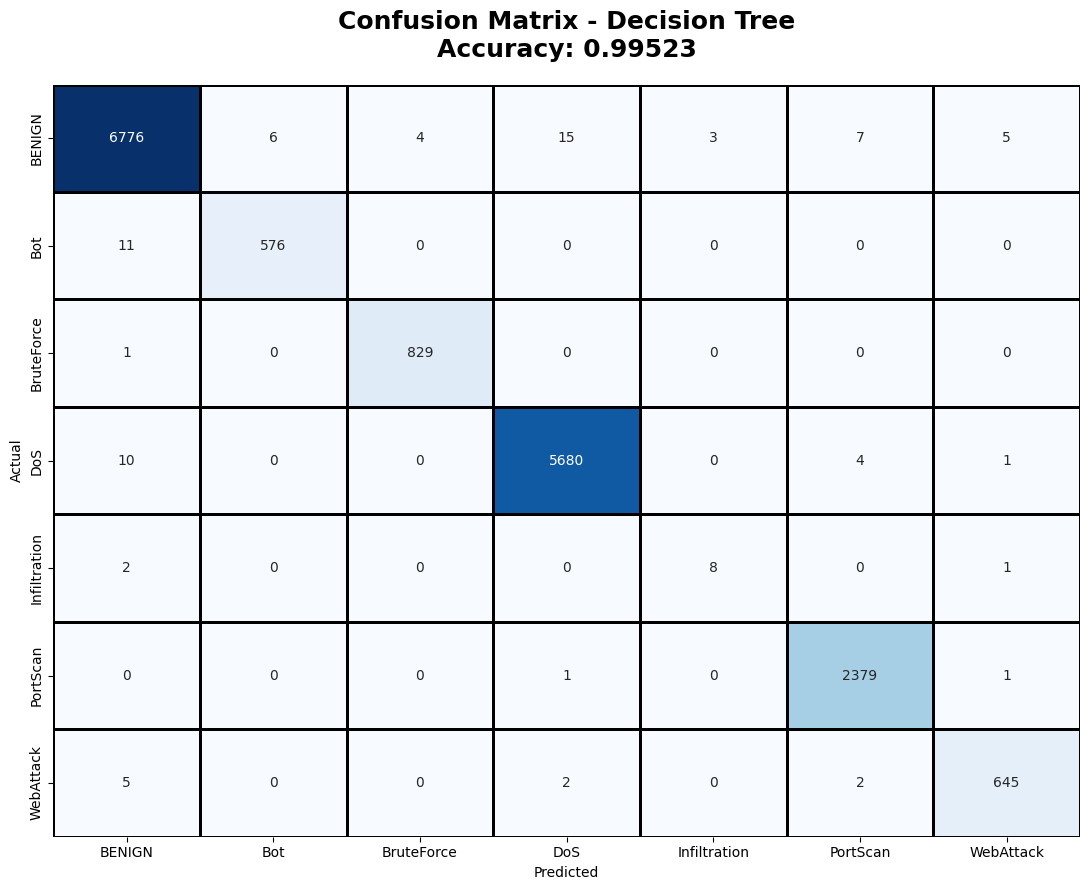

In [ ]:
best_model = models[final_results.iloc[0]['Model']]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(11,9))
sns.heatmap(confusion_matrix(y_test, y_pred_best),
            annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=1, linecolor='black')
plt.title(f"Confusion Matrix - {final_results.iloc[0]['Model']}\nAccuracy: {final_results.iloc[0]['Accuracy']}", 
          fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [56]:
# CELL 9: Classification Report of Best Model
print(f"CLASSIFICATION REPORT – {final_results.iloc[0]['Model']}\n")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

CLASSIFICATION REPORT – Decision Tree

              precision    recall  f1-score   support

      BENIGN       1.00      0.99      0.99      6816
         Bot       0.99      0.98      0.99       587
  BruteForce       1.00      1.00      1.00       830
         DoS       1.00      1.00      1.00      5695
Infiltration       0.73      0.73      0.73        11
    PortScan       0.99      1.00      1.00      2381
   WebAttack       0.99      0.99      0.99       654

    accuracy                           1.00     16974
   macro avg       0.96      0.95      0.96     16974
weighted avg       1.00      1.00      1.00     16974



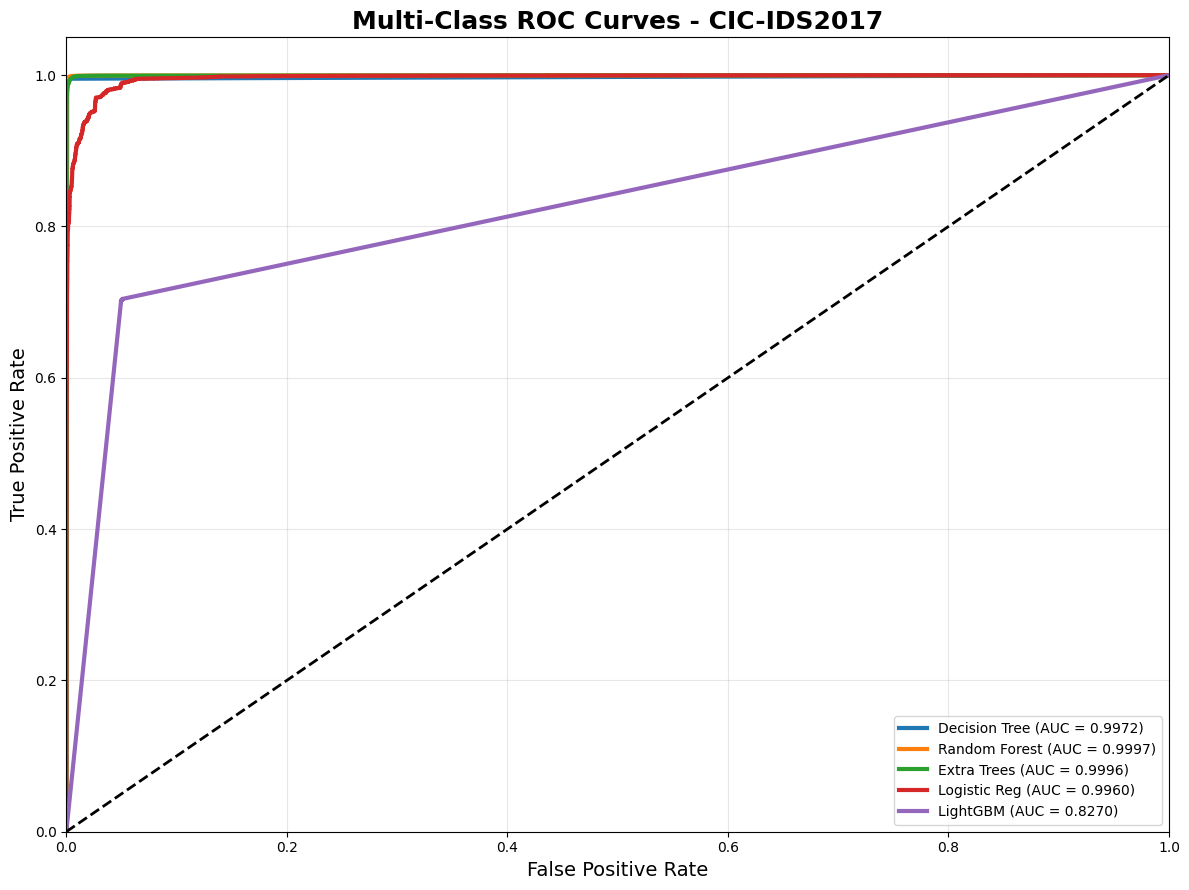

In [ ]:
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))

plt.figure(figsize=(12,9))
colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

for (name, model), color in zip(models.items(), colors):
    try:
        if hasattr(model, "predict_proba"):
            score = model.predict_proba(X_test)
        else:
            score = model.decision_function(X_test)
            from scipy.special import softmax
            score = softmax(score, axis=1)
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), score.ravel())
        plt.plot(fpr, tpr, color=color, lw=3, label=f'{name} (AUC = {auc(fpr,tpr):.4f})')
    except:
        pass

plt.plot([0,1], [0,1], 'k--', lw=2)
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Multi-Class ROC Curves - CIC-IDS2017', fontsize=18, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [59]:
import joblib
import os
from datetime import datetime

SAVE_DIR = "models"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Saving CIC-IDS2017 Multiclass models...\n")

for name, model in models.items():
    safe_name = name.replace(" ", "_").lower()
    filename = f"{SAVE_DIR}/cicids_multi_{safe_name}.pkl"
    joblib.dump(model, filename)
    print(f"SAVED → {filename}")

print("\nCIC-IDS2017 MULTICLASS MODELS SAVED SUCCESSFULLY!")

Saving CIC-IDS2017 Multiclass models...

SAVED → models/cicids_multi_decision_tree.pkl
SAVED → models/cicids_multi_random_forest.pkl
SAVED → models/cicids_multi_extra_trees.pkl
SAVED → models/cicids_multi_logistic_reg.pkl
SAVED → models/cicids_multi_lightgbm.pkl

CIC-IDS2017 MULTICLASS MODELS SAVED SUCCESSFULLY!
